# Unobserved Heterogeneity

We consider auctions with two bidders. Each bidder has the idiosyncratic valuation $V_i\sim F_i$
and the total valuation $Y+V_i$. The bids are $B_i=\beta_i(Y+V_i)=Y+\beta_i(V_i)=Y+A_i$, where
$A_i$ denotes the idiosyncratic bid.

## Monte Carlo Simulation

Assume $V_i\sim U[0,1]$. Assume $Y\sim N(0,1)$. Generate random valuations for $n=1000$ auctions. Generate idiosyncratic bids $A_i=\beta(V_i)$ using $\beta(x)=x/2$. Generate $B_i=Y+A_i$.

In [49]:
import numpy as np
import matplotlib.pyplot as plt

In [50]:
n = 1000

In [51]:
V1 = np.random.rand(1000)
V2 = np.random.rand(1000)

In [52]:
A1 = V1/2
A2 = V2/2

In [53]:
Y = np.random.randn(1000)

In [54]:
B1 = Y + A1
B2 = Y + A2

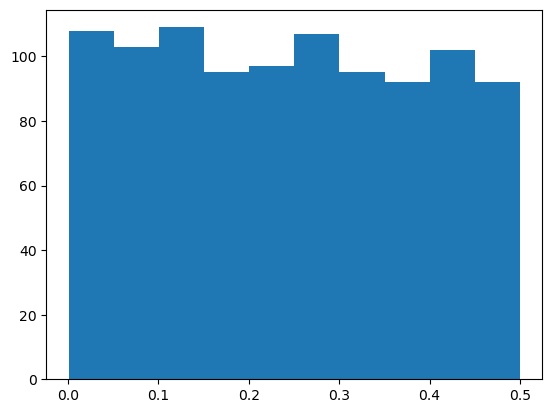

In [55]:
plt.hist(A1);

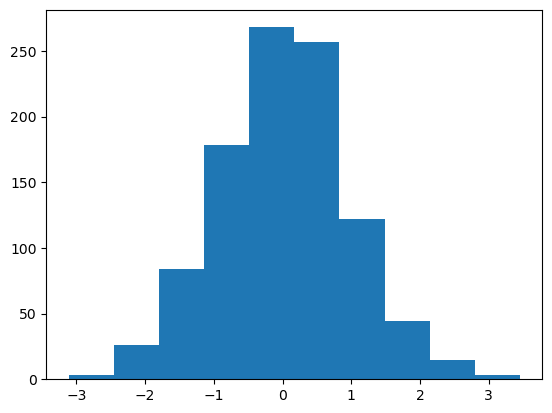

In [14]:
plt.hist(Y);

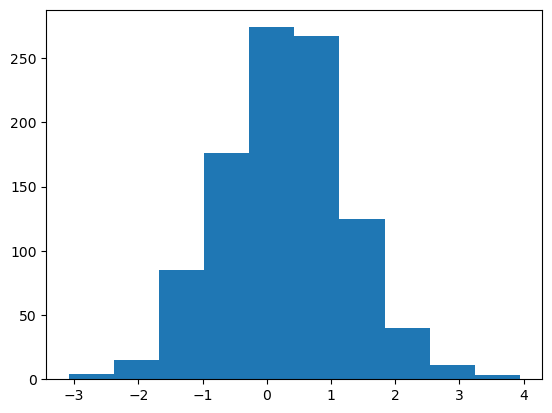

In [12]:
plt.hist(B1);

### Exercise
Write down functions that calculate the true characteristic functions $\Phi_Y$, $\Phi_1$, $\Phi_2$.

*Hint*: Approximate the integrals used by sums.

In [9]:
from scipy.stats import norm, uniform

In [44]:
grid = np.linspace(-10,10,1000)
large_grid = np.linspace(-50, 50, 1000)

In [46]:
def ΦYtrue(t):
    # integrate exp(ity) g_Y(y) from y=-inf to +inf
    y = grid
    return np.sum(np.exp(1j * t * y) * norm.pdf(y))/len(y)

def Φ1true(t):
    # integrate exp(i t a_1) g_1(a_1) from a1=-inf to +inf
    a1 = grid
    return np.sum(np.exp(1j * t * a1) * uniform.pdf(a1, scale=0.5))/len(a1)

def Φ2true(t):
    pass

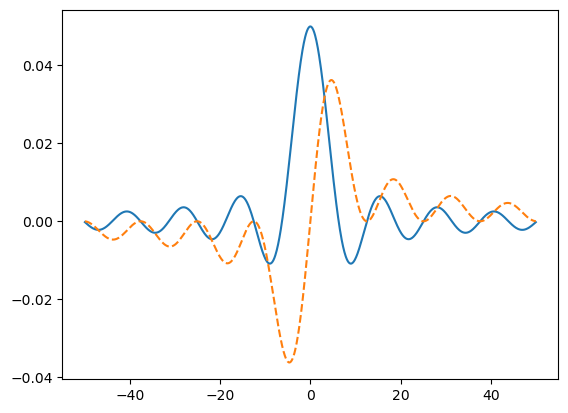

In [47]:
plt.plot(large_grid, np.real([Φ1true(t) for t in large_grid]))
plt.plot(large_grid, np.imag([Φ1true(t) for t in large_grid]), linestyle='--')

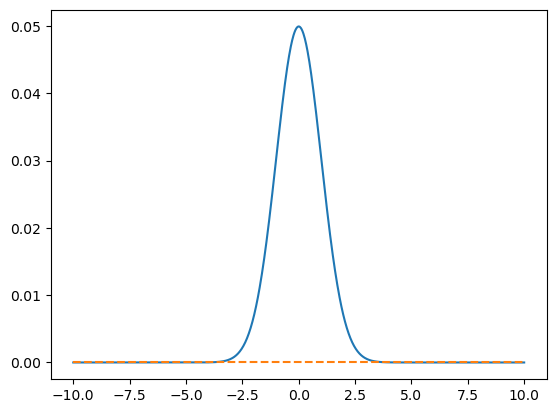

In [42]:
plt.plot(grid, np.real([ΦYtrue(t) for t in grid]))
plt.plot(grid, np.imag([ΦYtrue(t) for t in grid]), linestyle='--')

Plot the real and imaginary parts of $\Phi_Y$, $\Phi_1$, $\Phi_2$.

*Hint*: Use `np.real` and `np.imag` to get the real and imaginary parts.

## Estimation
Use the equations from the slides to estimate the underlying distributions.

First estimate $\hat\Psi$ and $\hat\Psi_1=\partial\hat\Psi/\partial t_1$.

In [57]:
def Ψ(t1, t2):
    return np.sum(np.exp(1j * t1 * B1 + 1j * t2 * B2))/len(B1)

In [58]:
Ψ(.2,3)

(-0.03070022795563427+0.009429879341136574j)

In [18]:
def Ψ1(t1, t2):
    pass # write code for estimate of Psi_1 here

Using $\hat\Psi$ and $\hat\Psi_1$ estimate $\hat\Phi_Y$ and then $\hat\Phi_1$ and $\hat\Phi_2$.

Compare the estimated characteristic functions to the true ones.

*Hint*: Approximate the integral for $\hat\Phi_Y$ with a sum.

In [19]:
def ΦY(t):
    pass

def Φ1(t):
    pass

def Φ2(t):
    pass

Estimate the idiosyncratic bid densities $g_1$ and $g_2$ using $\hat\Phi_1$ and $\Phi_2$.
Plot the estimated densities and compare then with the true densities.